<a href="https://colab.research.google.com/github/spentapa3-lgtm/deeplearning-/blob/main/lstml_for_text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 168ms/step - accuracy: 0.7875 - loss: 0.4442 - val_accuracy: 0.8610 - val_loss: 0.3296
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 163ms/step - accuracy: 0.8999 - loss: 0.2563 - val_accuracy: 0.8702 - val_loss: 0.3127
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 166ms/step - accuracy: 0.9302 - loss: 0.1858 - val_accuracy: 0.8698 - val_loss: 0.3334
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 159ms/step - accuracy: 0.9507 - loss: 0.1342 - val_accuracy: 0.8714 - val_loss: 0.3669
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 162ms/step - accuracy: 0.9622 - loss: 0.1072 - val_accuracy: 0.8424 - val_loss: 0.4151
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.8400 - loss: 0.4383
Test Accuracy: 0.839959979057312


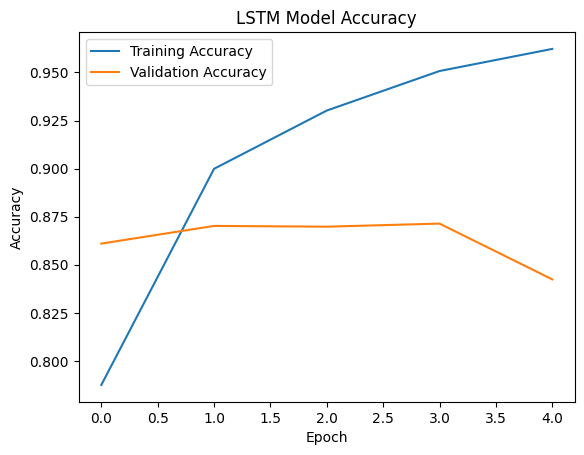

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt

vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length))

model.add(LSTM(64))


model.add(Dense(1, activation='sigmoid'))


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)


loss, accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", accuracy)


plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Model Accuracy")
plt.show()